In [1]:
from pybird.greenfunction import GreenFunction
from pybird.correlator import Correlator

import os, sys
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from classy import Class

dk, ds = 0.01, 5
kd = np.arange(0.005, 0.3, dk)
sd = np.arange(10, 200, ds)
z = 0.

# test greenfunction

In [2]:
G = GreenFunction(Omega0_m=0.3,fluid_equation_of_state = 'w0wa',
                  EoS_dict={'w0':-1.3,'wa':0.3,'alphaB':1},parameterizations='propto_omega',
                 EFTDE = True)
G.Y(a=1)


0.0010290988027035486

EFTDE works

# test correlator

In [3]:
outdir = '../data/eftboss/out'
with open(os.path.join(outdir, 'fit_boss_onesky_pk_wc_cmass_ngc_l0.dat')) as f: data_file = f.read()
eft_params_str = data_file.split(', \n')[1].replace("# ", "")
eft_params = {key: float(value) for key, value in (pair.split(': ') for pair in eft_params_str.split(', '))}
print (eft_params)

{'b1': 1.9605, 'c2': 0.6215, 'c4': 0.0, 'b3': -0.4816, 'cct': 0.3174, 'cr1': -0.8664, 'cr2': -0.8804, 'ce0': 1.3881, 'ce1': 0.0, 'ce2': -1.6003, 'b2': 0.4395, 'b4': 0.4395}


In [4]:
N = Correlator()
N.set({'output': 'bPf', 'multipole': 2, 'kmax': 0.3, 'xdata': kd,"with_exact_time":True,'EFTDE':True,'fluid_equation_of_state':'w0wa',
       'z': z,  
       'km': 0.7, 'kr': 0.35, 'nd': 3e-4, 
       'eft_basis': 'eftoflss', 'with_stoch': True,
       'EFTDE':True}) 

Input error in 'output'; input configs: ['bPk', 'bCf', 'mPk', 'mCf', 'bmPk', 'bmCf']. Check Correlator.info() in any doubt.
Input error in 'EFTDE'; input configs: ['str']. Check Correlator.info() in any doubt.


In [5]:
M=Class()
cosmo = {'omega_b': 0.02235, 'omega_cdm': 0.120, 'h': 0.675, 'ln10^{10}A_s': 3.044, 'n_s': 0.965}

hiset={
    'Omega_smg':-1,
    'Omega_fld':0,
    'Omega_Lambda':0,
    
    'gravity_model':'propto_omega',
    'parameters_smg':'0.,0.6,0,0,1',
    'expansion_model':'w0wa',
    'expansion_smg':'0.7,-0.8,-0.7',
    #'expansion_model':'lcdm',
    #'expansion_smg':'0.6',
    'skip_stability_tests_smg':'n',
    # 'cs2_safe_smg':10.,
    #'D_safe_smg':10.,
    # 'ct2_safe_smg':10.,
    # 'M2_safe_smg':10.,
    #'method_qs_smg':'automatic'
}
M.set(cosmo)
M.set(hiset)
M.set({'output':'tCl,mPk'})
M.compute()

In [6]:
M.get_current_derived_parameters(['parameters_2_smg_real__1'])

{'parameters_2_smg_real__1': 0.0}

In [7]:
M.get_current_derived_parameters(['parameters_2_smg_real__2'])

{'parameters_2_smg_real__2': 0.6}

In [8]:
M.get_current_derived_parameters(['parameters_2_smg_real__3'])

{'parameters_2_smg_real__3': 0.0}

In [9]:
M.get_current_derived_parameters(['w0_fld'])['w0_fld']

-0.8

In [10]:
M.get_current_derived_parameters(['wa_fld'])['wa_fld']

-0.7

In [11]:
M.get_current_derived_parameters(['parameters_smg_real__1'])

{'parameters_smg_real__1': 0.6874802175879597}

In [12]:
M.get_current_derived_parameters(['parameters_smg_real__2'])

{'parameters_smg_real__2': -0.8}

In [13]:
M.get_current_derived_parameters(['parameters_smg_real__3'])

{'parameters_smg_real__3': -0.7}

Input error in 'EFTDE'; input configs: ['str']. Check Correlator.info() in any doubt.


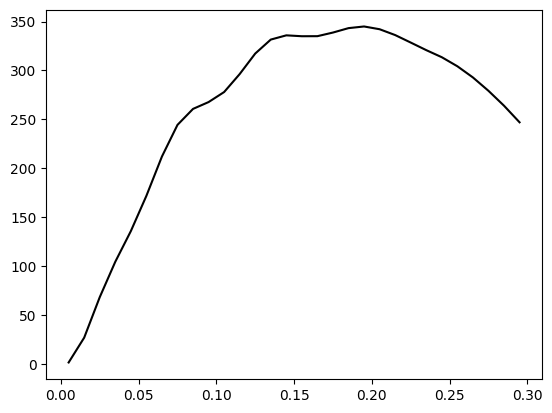

In [14]:
N.compute(cosmo, cosmo_module='class', cosmo_engine=M) 
bPk = N.get(eft_params)
plt.plot(kd,kd**2*bPk[0],'k')